**Description Of the features of the dataset:**


Y – Latitude coordinate of the observation station.

X – Longitude coordinate of the observation station.

data_payload_id – Unique identifier for the data record.

instance_datetime – Timestamp when the data was recorded.

url – URL reference to the data source.

agency – Organization responsible for the data.

platform_type – Type of platform (e.g., station, balloon, etc.).

platform_id – Numeric ID for the platform.

platform_name – Name of the observation platform or station.

gaw_id – Global Atmosphere Watch ID of the platform.

instrument_name – Name of the instrument used for measurement.

instrument_model – Model of the instrument.

instrument_number – Instrument's identification number.

monthly_date – Date associated with monthly aggregated data.

monthly_columno3 – Monthly average ozone column value.

monthly_stddevo3 – Standard deviation of the monthly ozone values.

monthly_npts – Number of observations used in monthly average.

daily_date – Date of the daily observation.

daily_wlcode – Wavelength code used during observation.

daily_obscode – Observation code (e.g., method or technique).

daily_columno3 – Daily ozone column measurement (Dobson Units).

daily_stddevo3 – Standard deviation of the daily ozone value.

daily_utc_begin – UTC time when observation began.

daily_utc_end – UTC time when observation ended.

daily_utc_mean – Mean UTC time of observation.

daily_nobs – Number of observations for that day.

daily_mmu – Measurement uncertainty for daily ozone.

daily_columnso2 – Daily SO₂ (sulfur dioxide) column measurement.

latest_observation – Flag indicating if this is the most recent data (0 or 1).

country – Country of the observation station.

scientific_authority – Name of the responsible scientist or authority.

version – Version number of the data record.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.linear_model import  LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler ,MinMaxScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

In [4]:
df=pd.read_csv('New Dataset/spain.csv')
df.head()


,Y,X,data_payload_id,instance_datetime,url,agency,platform_type,platform_id,platform_name,gaw_id,...,daily_utc_begin,daily_utc_end,daily_utc_mean,daily_nobs,daily_mmu,daily_columnso2,latest_observation,country,scientific_authority,version
0,28.46,-16.25,2306481,2025/03/05 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,AEMET,STN,401,Santa Cruz (Tenerife),SCO,...,9.15,10.52,9.60,4.0,2.181,-0.5,0,ESP,MIGUEL HERNANDEZ MARTINEZ DE LA PEÑA,0.0
1,28.46,-16.25,2306502,2025/03/05 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,AEMET,STN,401,Santa Cruz (Tenerife),SCO,...,12.50,17.88,15.22,12.0,1.421,-1.4,0,ESP,MIGUEL HERNANDEZ MARTINEZ DE LA PEÑA,0.0
2,28.46,-16.25,2306482,2025/03/05 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,AEMET,STN,401,Santa Cruz (Tenerife),SCO,...,8.85,14.03,10.80,16.0,1.638,-0.9,0,ESP,MIGUEL HERNANDEZ MARTINEZ DE LA PEÑA,0.0
3,28.46,-16.25,2306480,2025/03/05 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,AEMET,STN,401,Santa Cruz (Tenerife),SCO,...,12.83,17.27,15.41,10.0,1.602,-0.6,0,ESP,MIGUEL HERNANDEZ MARTINEZ DE LA PEÑA,0.0
4,28.46,-16.25,2306483,2025/03/05 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,AEMET,STN,401,Santa Cruz (Tenerife),SCO,...,9.55,17.55,15.04,19.0,1.680,-0.8,0,ESP,MIGUEL HERNANDEZ MARTINEZ DE LA PEÑA,0.0


In [5]:
df=df.drop(['Y', 'X', 'data_payload_id', 'instance_datetime', 'url', 'agency',
       'platform_type', 'platform_id', 'platform_name', 'gaw_id',
       'instrument_name', 'instrument_model', 'instrument_number',
       'monthly_date', 'monthly_stddevo3', 'monthly_npts','daily_stddevo3',
        'daily_wlcode', 'daily_obscode', 'monthly_columno3',
        'daily_utc_begin', 'daily_utc_end', 'daily_utc_mean',
       'daily_nobs', 'daily_mmu', 'daily_columnso2', 'latest_observation',
       'country', 'scientific_authority', 'version'], axis = 1)
df.head()

,daily_date,daily_columno3
0,2025-03-06,280.5
1,2025-03-27,310.2
2,2025-03-07,306.3
3,2025-03-05,319.4
4,2025-03-08,313.9


In [6]:
print(f"Date Range: {df.loc[:,'daily_date'][len(df)-1]} to {df.loc[:,'daily_date'][0]}")

Date Range: 1976-01-21 to 2025-03-06


In [7]:
df=df.drop_duplicates()
df=df.dropna()
# df=df.set_index('daily_date')
df.head()


,daily_date,daily_columno3
0,2025-03-06,280.5
1,2025-03-27,310.2
2,2025-03-07,306.3
3,2025-03-05,319.4
4,2025-03-08,313.9


In [8]:
round(df.describe(), 3)

,daily_columno3
count,65510.000
mean,310.114
std,34.389
min,-91.500
25%,286.000
50%,305.000
75%,328.600
max,521.800


In [9]:
df.head()
df.dtypes

daily_date         object
daily_columno3    float64
dtype: object

<Figure size 1200x600 with 0 Axes>

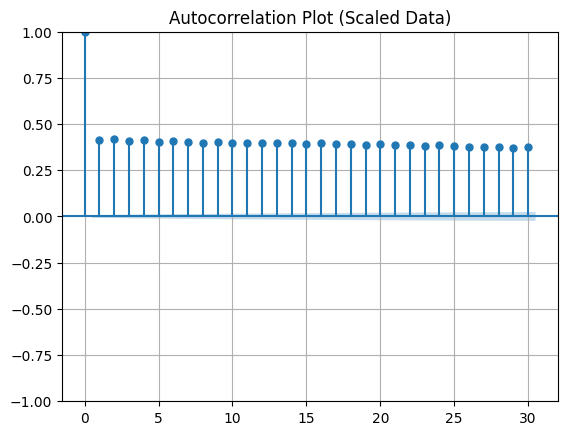

✅ Autocorrelation remains significant for all plotted lags.


In [10]:

acf_vals, confint = acf(df['daily_columno3'], nlags=30, alpha=0.05)

# 4. Calculate threshold from confidence interval
threshold = (confint[:,1] - confint[:,0]) / 2

# 5. Find first inconsistent lag
inconsistent_lag = None
for i, val in enumerate(acf_vals):
    if i == 0:  # Skip lag 0
        continue
    if abs(val) < threshold[i]:
        inconsistent_lag = i
        break

# 6. Plot ACF
plt.figure(figsize=(12,6))
plot_acf(df['daily_columno3'], lags=30, alpha=0.05)
plt.title('Autocorrelation Plot (Scaled Data)')
plt.grid()
plt.show()

# 7. Print result
if inconsistent_lag:
    print(f"👉 Autocorrelation becomes inconsistent after lag {inconsistent_lag}.")
else:
    print("✅ Autocorrelation remains significant for all plotted lags.")



In [11]:
df.head()

,daily_date,daily_columno3
0,2025-03-06,280.5
1,2025-03-27,310.2
2,2025-03-07,306.3
3,2025-03-05,319.4
4,2025-03-08,313.9


In [17]:
# Impute (fill) missing values in feature columns using forward fill (you can choose other methods if needed)
feature_cols = ['rolling_avg'] + [f'lag{i}' for i in range(1, 16)]
df[feature_cols] = df[feature_cols].fillna(method='ffill')  # or use .fillna(0) if preferred

# Final dropna to remove any remaining NaNs (e.g., early rows with insufficient lag values)
df = df.dropna()
df = df.drop_duplicates()

# Show resulting shape and samples
print("Data shape after cleaning:", df.shape)
print(df.head())
print(df.tail())


Data shape after cleaning: (65480, 18)
    daily_date  daily_columno3  rolling_avg      lag1      lag2      lag3  \
15  1976-09-07        0.595630     0.613620  0.621066  0.606718  0.613077   
16  1976-09-08        0.613077     0.607805  0.595630  0.621066  0.606718   
17  1976-09-09        0.611446     0.609924  0.613077  0.595630  0.621066   
18  1976-09-10        0.611446     0.606718  0.611446  0.613077  0.595630   
19  1976-09-13        0.651231     0.611990  0.611446  0.611446  0.613077   

        lag4      lag5      lag6      lag7      lag8      lag9     lag10  \
15  0.622534  0.630523  0.643241  0.638513  0.635252  0.630523  0.636882   
16  0.613077  0.622534  0.630523  0.643241  0.638513  0.635252  0.630523   
17  0.606718  0.613077  0.622534  0.630523  0.643241  0.638513  0.635252   
18  0.621066  0.606718  0.613077  0.622534  0.630523  0.643241  0.638513   
19  0.595630  0.621066  0.606718  0.613077  0.622534  0.630523  0.643241   

       lag11     lag12     lag13     lag1

In [18]:
scaler = MinMaxScaler()
df['daily_columno3'] = scaler.fit_transform(df[['daily_columno3']])
df['rolling_avg'] = scaler.fit_transform(df[['rolling_avg']])
df['lag1'] = scaler.fit_transform(df[['lag1']])
df['lag2'] = scaler.fit_transform(df[['lag2']])
df['lag3'] = scaler.fit_transform(df[['lag3']])
df['lag4'] = scaler.fit_transform(df[['lag4']])
df['lag5'] = scaler.fit_transform(df[['lag5']])
df['lag6'] = scaler.fit_transform(df[['lag6']])
df['lag7'] = scaler.fit_transform(df[['lag7']])
df['lag8'] = scaler.fit_transform(df[['lag8']])
df['lag9'] = scaler.fit_transform(df[['lag9']])
df['lag10'] = scaler.fit_transform(df[['lag10']])
df['lag11'] = scaler.fit_transform(df[['lag11']])
df['lag12'] = scaler.fit_transform(df[['lag12']])
df['lag13'] = scaler.fit_transform(df[['lag13']])
df['lag14'] = scaler.fit_transform(df[['lag14']])
df['lag15'] = scaler.fit_transform(df[['lag15']])
df.head()

,daily_date,daily_columno3,rolling_avg,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag8,lag9,lag10,lag11,lag12,lag13,lag14,lag15
15,1976-09-07,0.595630,0.386655,0.621066,0.606718,0.613077,0.622534,0.630523,0.643241,0.638513,0.635252,0.630523,0.636882,0.627425,0.622534,0.633784,0.651231,0.647970
16,1976-09-08,0.613077,0.375950,0.595630,0.621066,0.606718,0.613077,0.622534,0.630523,0.643241,0.638513,0.635252,0.630523,0.636882,0.627425,0.622534,0.633784,0.651231
17,1976-09-09,0.611446,0.379852,0.613077,0.595630,0.621066,0.606718,0.613077,0.622534,0.630523,0.643241,0.638513,0.635252,0.630523,0.636882,0.627425,0.622534,0.633784
18,1976-09-10,0.611446,0.373950,0.611446,0.613077,0.595630,0.621066,0.606718,0.613077,0.622534,0.630523,0.643241,0.638513,0.635252,0.630523,0.636882,0.627425,0.622534
19,1976-09-13,0.651231,0.383653,0.611446,0.611446,0.613077,0.595630,0.621066,0.606718,0.613077,0.622534,0.630523,0.643241,0.638513,0.635252,0.630523,0.636882,0.627425


Model Evaluation Metrics:

----- Linear Regression -----
RMSE: 0.039
MAE : 0.028
R2  : 50.64 %

----- Decision Tree -----
RMSE: 0.054
MAE : 0.039
R2  : 1.79 %

----- Random Forest -----
RMSE: 0.039
MAE : 0.028
R2  : 49.82 %

----- Gradient Boosting -----
RMSE: 0.039
MAE : 0.028
R2  : 50.34 %

----- Support Vector Regressor -----
RMSE: 0.045
MAE : 0.037
R2  : 31.26 %



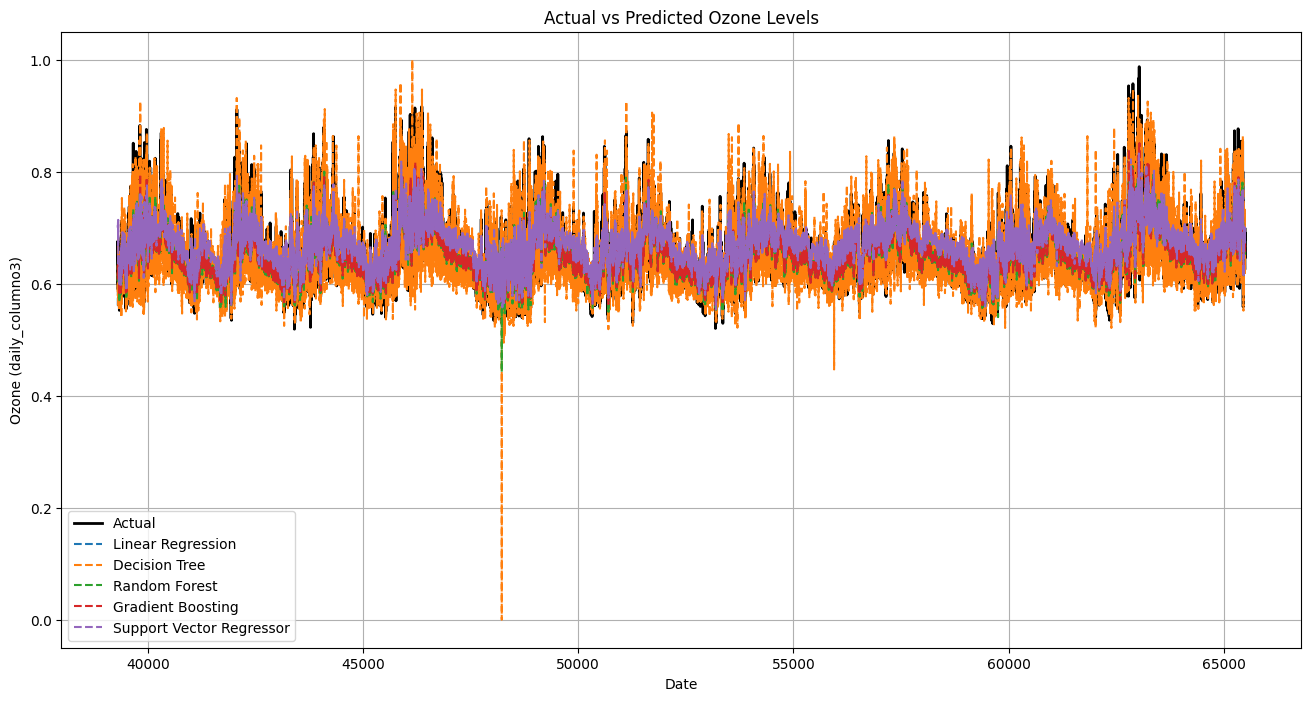

In [19]:

X = df[['lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7',
        'lag8', 'lag9', 'lag10', 'lag11', 'lag12', 'lag13', 'lag14', 'lag15','rolling_avg']]
y = df['daily_columno3']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, shuffle=False)

# STEP 3: Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector Regressor': SVR()
}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# STEP 6: Plot actual vs predicted
plt.figure(figsize=(16, 8))

# Actual data
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(y_test.index, res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Date')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()
